In [ ]:
import os, json, cv2, torch, numpy as np, pandas as pd, requests, matplotlib.pyplot as plt
import torch.nn.functional as F
from PIL import Image
from datetime import datetime
from typing import Optional, Dict, Any
from google.colab import files
from IPython.display import display

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Model Load

In [ ]:
ROOT = "/content/drive/MyDrive/FoodSeg103_2"
ID2LABEL_PATH   = f"{ROOT}/id2label_final.json"
CHECKPOINT_PATH = f"{ROOT}/segformer_b3_512x384_ckpts/segformer_b3_best_miou_EMA_0.444.pt"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
INPUT_SIZE = (384, 512)

# Load label dictionary
with open(ID2LABEL_PATH, "r") as f:
    id2label: Dict[str, str] = json.load(f)
IDX2NAME = [name for idx, name in sorted(id2label.items(), key=lambda kv: int(kv[0]))]
NUM_CLASSES = len(IDX2NAME)

def load_model():
    from transformers import SegformerForSemanticSegmentation
    model = SegformerForSemanticSegmentation.from_pretrained(
        "nvidia/segformer-b3-finetuned-ade-512-512",
        num_labels=NUM_CLASSES,
        ignore_mismatched_sizes=True).to(DEVICE)
    model.eval()
    state = torch.load(CHECKPOINT_PATH, map_location="cpu")
    model.load_state_dict(state.get("model_ema", state.get("model", state)), strict=False)
    return model

model = load_model()
print("Model ready on:", DEVICE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/190M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/189M [00:00<?, ?B/s]

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b3-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.weight: found shape torch.Size([150, 768, 1, 1]) in the checkpoint and torch.Size([76, 768, 1, 1]) in the model instantiated
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([76]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model ready on: cpu


In [ ]:
id2label_path = "/content/drive/MyDrive/FoodSeg103_2/id2label_final.json"  # Update this accordingly
with open(id2label_path, 'r') as f:
    id2label = json.load(f)

In [ ]:
nutrition_db = {
    "background": {"ingredient": "background", "calories": 0, "protein": 0, "fat": 0}
}

api_key = "UPA9aRGyC9OebZ6fIPLGby8pIhoqrd499nxtt5Wj"
def get_nutrition(ingredient):
    url = f"https://api.nal.usda.gov/fdc/v1/foods/search?query={ingredient}&api_key={api_key}"
    response = requests.get(url)
    data = response.json()
    # Extract relevant nutritional values
    if 'foods' in data and len(data['foods']) > 0:
        food = data['foods'][0]
        nutrients = {
            nutrient['nutrientName']: nutrient['value']
            for nutrient in food['foodNutrients']
            if nutrient['nutrientName'] in ['Energy', 'Protein', 'Total lipid (fat)']
        }
        return {
            "ingredient": ingredient,
            "calories": nutrients.get('Energy', 0),
            "protein": nutrients.get('Protein', 0),
            "fat": nutrients.get('Total lipid (fat)', 0)
        }
    return {"ingredient": ingredient, "calories": 0, "protein": 0, "fat": 0}

for class_id, ingredient in id2label.items():
    if ingredient.lower() != "background":
        nutrition_db[ingredient] = get_nutrition(ingredient)
        print(f"Fetched data for: {ingredient}")
    else:
        print(f"Skipping background")


Skipping background
Fetched data for: french fries
Fetched data for: chocolate
Fetched data for: biscuit
Fetched data for: ice cream
Fetched data for: cheese butter
Fetched data for: cake
Fetched data for: wine
Fetched data for: milkshake
Fetched data for: coffee
Fetched data for: juice
Fetched data for: milk
Fetched data for: almond
Fetched data for: soy
Fetched data for: walnut
Fetched data for: egg
Fetched data for: apple
Fetched data for: avocado
Fetched data for: banana
Fetched data for: strawberry
Fetched data for: cherry
Fetched data for: blueberry
Fetched data for: raspberry
Fetched data for: mango
Fetched data for: olives
Fetched data for: peach
Fetched data for: lemon
Fetched data for: pear
Fetched data for: pineapple
Fetched data for: grape
Fetched data for: kiwi
Fetched data for: orange
Fetched data for: watermelon
Fetched data for: steak
Fetched data for: pork
Fetched data for: chicken duck
Fetched data for: sausage
Fetched data for: fried meat
Fetched data for: lamb
Fetch

In [ ]:
import json

output_path = "/content/drive/MyDrive/FoodSeg103_2/nutrition_db.json"
with open(output_path, "w") as f:
    json.dump(nutrition_db, f, indent=2)
print(f"Nutrition data saved to: {output_path}")

Nutrition data saved to: /content/drive/MyDrive/FoodSeg103_2/nutrition_db.json


# MINI DASHBOARD

Saving peas-and-carrots-1.jpg to peas-and-carrots-1 (5).jpg


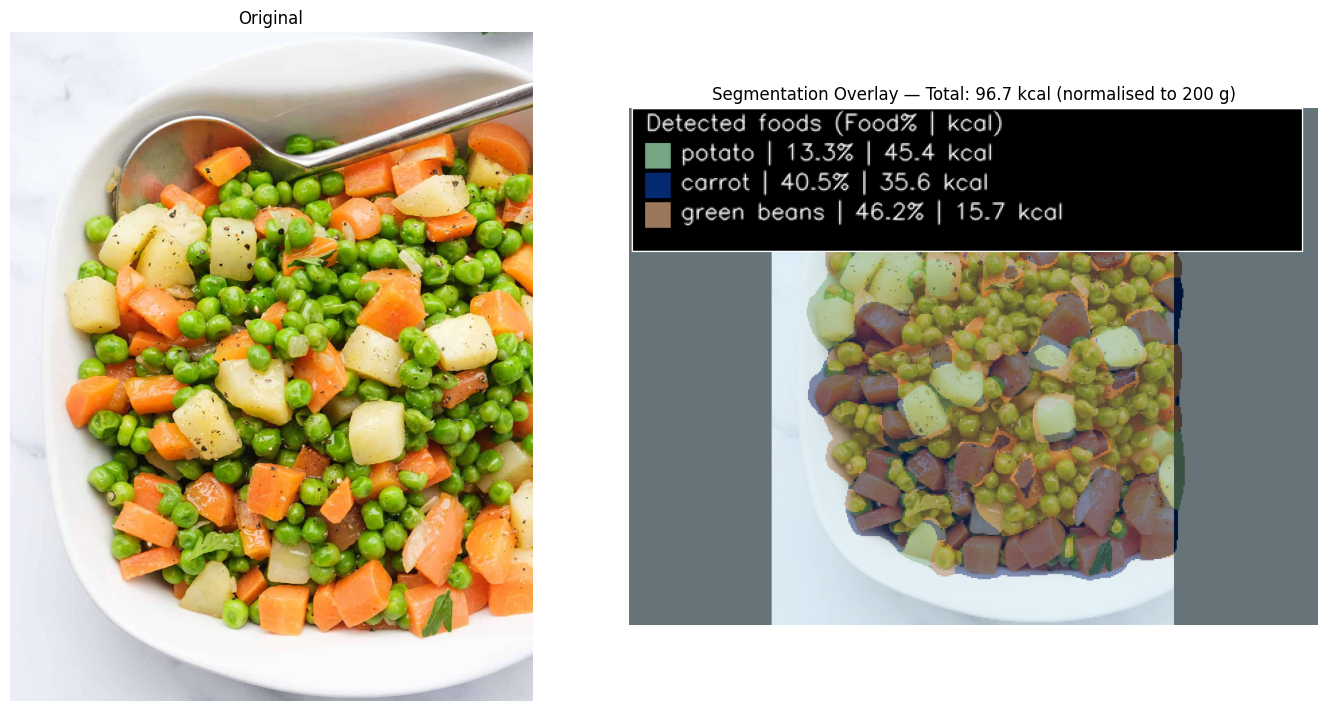

Total estimated calories (food-only, normalised to 200 g): 96.7 kcal

Detections (filtered):


,class_name,food_area_%,image_area_%,mean_conf,pixels
0,green beans,46.242830,17.302958,0.929831,34019
1,carrot,40.487453,15.149434,0.905870,29785
2,potato,13.269717,4.965210,0.792547,9762



Calorie table (breakdown used in legend):


,class_id,class,food_area_%,image_area_%,grams_200g,kcal_per_g,kcal,mean_conf
0,52,potato,13.27,4.97,26.5,1.71,45.4,0.793
1,62,carrot,40.49,15.15,81.0,0.44,35.6,0.906
2,71,green beans,46.24,17.30,92.5,0.17,15.7,0.930


Saved overlay to: overlay_peas-and-carrots-1 (5)_20250828_023606.png


In [ ]:
from google.colab import files
from PIL import Image
import numpy as np, pandas as pd, cv2, os, time
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt

INPUT_SIZE       = (384, 512)
REF_SERVING_G    = 200.0
MIN_PIXELS       = 500
BACKGROUND_SET   = {"background", "bg", "void", "other", "others"}
LEGEND_MAX_ITEMS = 12

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert "model" in globals(), "Please load your model into a variable named `model`."
assert "IDX2NAME" in globals(), "Please define `IDX2NAME` as a list of class names by index."
if "nutrition_db" not in globals():
    print("nutrition_db` not found — unmapped classes will contribute 0 kcal.")
    nutrition_db = {}

def letterbox_and_tensor(pil, size=INPUT_SIZE):
    img = np.array(pil.convert("RGB"))
    Ht, Wt = size
    h, w = img.shape[:2]
    scale = min(Wt / w, Ht / h)
    nw, nh = int(w * scale), int(h * scale)
    resized = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_LINEAR)
    canvas = np.zeros((Ht, Wt, 3), dtype=np.uint8)
    y0 = (Ht - nh) // 2; x0 = (Wt - nw) // 2
    canvas[y0:y0+nh, x0:x0+nw] = resized
    x = canvas.astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    x = (x - mean) / std
    x = torch.from_numpy(x).permute(2,0,1).unsqueeze(0).float().to(DEVICE)  # (1,3,H,W)
    return x, canvas

def kcal_per_g_from_db(name: str) -> float:
    info = nutrition_db.get(name, {})
    if isinstance(info, dict):
        if "kcal_per_gram" in info: return float(info["kcal_per_gram"])
        if "calories" in info:      return float(info["calories"]) / 100.0  # kcal per 100 g → per g
    return 0.0

_rng = np.random.default_rng(123)
def get_palette(n):
    return _rng.integers(0, 255, (n, 3), dtype=np.uint8)

def overlay_with_legend(canvas_rgb, mask, legend_rows, palette):
    colored = palette[mask]
    overlay = (0.5*canvas_rgb.astype(np.float32) + 0.5*colored.astype(np.float32)).astype(np.uint8)

    vis = overlay.copy()
    h, w = vis.shape[:2]; x0, y0 = 12, 16
    line_h, fs, th = 22, 0.55, 1
    items = legend_rows[:LEGEND_MAX_ITEMS]
    if items:
        box_h = 22 + len(items)*(line_h+6)
        cv2.rectangle(vis, (x0-10,y0-16), (min(560,w-12), y0-16+box_h), (0,0,0), -1)
        cv2.rectangle(vis, (x0-10,y0-16), (min(560,w-12), y0-16+box_h), (255,255,255), 1)
        y = y0
        cv2.putText(vis, "Detected foods (Food% | kcal)", (x0,y), cv2.FONT_HERSHEY_SIMPLEX, fs, (255,255,255), th, cv2.LINE_AA)
        y += line_h
        for r in items:
            cid  = int(r.get("class_id", 0))
            name = r.get("class_name", r.get("class", ""))
            food_pct = float(r.get("food_area_%", 0.0))
            kcal_val = r.get("kcal", None)
            kcal_txt = f"{float(kcal_val):.1f}" if (kcal_val is not None and np.isfinite(kcal_val)) else "—"
            cid_clamped = min(max(cid, 0), len(palette)-1)
            sw = tuple(int(v) for v in palette[cid_clamped])
            cv2.rectangle(vis, (x0, y-12), (x0+18, y+6), sw, -1)
            label = f'{name} | {food_pct:.1f}% | {kcal_txt} kcal'
            cv2.putText(vis, label, (x0+26,y), cv2.FONT_HERSHEY_SIMPLEX, fs, (255,255,255), th, cv2.LINE_AA)
            y += line_h
    return vis

# ---- upload ----
up = files.upload()
img_path = next(iter(up.keys()))
pil_img = Image.open(img_path).convert("RGB")

# ---- inference ----
model.eval()
x, canvas = letterbox_and_tensor(pil_img, INPUT_SIZE)
with torch.no_grad():
    out = model(x)
logits = out["logits"] if isinstance(out, dict) and "logits" in out else out
H, W = x.shape[-2], x.shape[-1]
probs = F.softmax(F.interpolate(logits, size=(H, W), mode="bilinear", align_corners=False), dim=1)
conf_map, pred_mask_t = probs.max(dim=1)
pred_mask = pred_mask_t[0].cpu().numpy().astype(np.int32)
conf_map = conf_map[0].cpu().numpy().astype(np.float32)

# ---- detections (exclude background + tiny) ----
total_pix = pred_mask.size
rows = []
for cls_id in np.unique(pred_mask):
    cname = IDX2NAME[cls_id].strip()
    if cname.lower() in BACKGROUND_SET:
        continue
    cls_pix = (pred_mask == cls_id)
    pix = int(cls_pix.sum())
    if pix < MIN_PIXELS:
        continue
    rows.append({
        "class_id": int(cls_id),
        "class_name": cname,
        "pixels": pix,
        "image_area_%": 100.0 * pix / total_pix,
        "mean_conf": float(conf_map[cls_pix].mean()) if pix > 0 else 0.0
    })
det_df = pd.DataFrame(rows).sort_values("pixels", ascending=False).reset_index(drop=True)
food_pixels = det_df["pixels"].sum() if not det_df.empty else 0
det_df["food_area_%"] = (100.0 * det_df["pixels"] / food_pixels) if food_pixels > 0 else 0.0

per_item = []
total_kcal = 0.0
for _, r in det_df.iterrows():
    cname = r["class_name"]
    share = (r["pixels"] / max(food_pixels, 1))
    grams = REF_SERVING_G * share
    kcpg  = kcal_per_g_from_db(cname)
    kcal  = grams * kcpg
    total_kcal += kcal
    per_item.append({
        "class_id": int(r["class_id"]),
        "class": cname,  # note: 'class' to be compatible with earlier code
        "food_area_%": round(r["food_area_%"], 2),
        "image_area_%": round(r["image_area_%"], 2),
        "grams_200g": round(grams, 1),
        "kcal_per_g": round(kcpg, 4),
        "kcal": round(kcal, 1),
        "mean_conf": round(r["mean_conf"], 3)
    })
cal_df = pd.DataFrame(per_item).sort_values("kcal", ascending=False).reset_index(drop=True)

palette = get_palette(len(IDX2NAME))
overlay = overlay_with_legend(
    canvas_rgb=canvas,
    mask=pred_mask,
    legend_rows=cal_df.to_dict(orient="records"),  # accepts 'class' or 'class_name'
    palette=palette
)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
axes[0].imshow(pil_img); axes[0].axis('off'); axes[0].set_title("Original")
axes[1].imshow(overlay); axes[1].axis('off')
axes[1].set_title(f"Segmentation Overlay — Total: {total_kcal:.1f} kcal (normalised to {REF_SERVING_G:.0f} g)")
plt.show()

print(f"Total estimated calories (food-only, normalised to {REF_SERVING_G:.0f} g): {total_kcal:.1f} kcal")
print("\nDetections (filtered):")
display(det_df[["class_name","food_area_%","image_area_%","mean_conf","pixels"]])
print("\nCalorie table (breakdown used in legend):")
display(cal_df)

stamp = time.strftime("%Y%m%d_%H%M%S")
out_path = f"overlay_{os.path.splitext(os.path.basename(img_path))[0]}_{stamp}.png"
cv2.imwrite(out_path, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
print("Saved overlay to:", out_path)